# CasTuner — real FCS subset (end-to-end mini run)

This notebook runs the *real* gating → median extraction → fitting pipeline on a **tiny subset** of your `.fcs` files.

It is designed to:
- confirm your file naming is parsed correctly,
- confirm gating/medians work,
- produce the same parameter CSVs as the full scripts, but from **just a few files**.

**Expected folder layout (relative to this notebook):**
```
fcs_files/
  NFC/                          # negative controls
  time-course_data/             # KD + Rev time courses
  dose_response_data/
    R1/ R2/ R3/                 # dose-response replicates
```

If those folders are not present, this notebook will stop and print what’s missing.


In [2]:
import os, sys, re, glob, shutil, tempfile
from pathlib import Path
import numpy as np
import pandas as pd

# Optional: make plots visible in-notebook
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve().parent
FCS_ROOT = PROJECT_ROOT / "fcs_files"

required = [
    FCS_ROOT / "NFC",
    FCS_ROOT / "time-course_data",
    FCS_ROOT / "dose_response_data" / "R1",
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    print("Missing required folders:")
    for p in missing:
        print(" -", p)
    raise SystemExit("Create the expected folder structure (see notebook header) and re-run.")

print("OK: found required folders under", FCS_ROOT)


OK: found required folders under /home/abhinavmishra/git/CasTuner/fcs_files


## 1) Import your step scripts as modules

We load your scripts directly so we can call their functions from the notebook.


In [6]:
import importlib.util

def load_module(py_path: str, name: str):
    py_path = str(Path(py_path).resolve())
    spec = importlib.util.spec_from_file_location(name, py_path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

step1a = load_module(f"{PROJECT_ROOT}/scripts/step_1a_fit_upregulation.py", "step1a")
step1b = load_module(f"{PROJECT_ROOT}/scripts/step_1b_fit_downregulation.py", "step1b")
step1c = load_module(f"{PROJECT_ROOT}/scripts/step_1c_fit_hill_curves.py", "step1c")

print("Loaded:", step1a.__name__, step1b.__name__, step1c.__name__)


Loaded: step1a step1b step1c


## 2) Choose a tiny subset of files

We:
- use **all NFC files** (usually small; needed for background medians),
- pick **one plasmid**, **one replicate**, and **a few times** from `time-course_data`,
- pick **one dose-response replicate folder** (R1) and keep a small number of files.

You can change the filters below.


In [7]:
# ---- user controls ----
PLASMID_KEEP = None   # e.g. "SP411" or "SP430" or None to auto-detect
REP_KEEP = None       # e.g. "R1" or "R2" or None to auto-detect
MAX_TIMECOURSE_FILES = 18  # keep KD+Rev combined
MAX_DOSERESP_FILES = 18
DOSE_REP_FOLDER = "R1"     # R1/R2/R3

tc_files = sorted((FCS_ROOT / "time-course_data").glob("*.fcs"))
dr_files = sorted((FCS_ROOT / "dose_response_data" / DOSE_REP_FOLDER).glob("*.fcs"))
nfc_files = sorted((FCS_ROOT / "NFC").glob("*.fcs"))

print(f"NFC: {len(nfc_files)} files")
print(f"Time-course: {len(tc_files)} files")
print(f"Dose-response {DOSE_REP_FOLDER}: {len(dr_files)} files")

if not tc_files:
    raise SystemExit("No time-course .fcs files found.")
if not dr_files:
    raise SystemExit("No dose-response .fcs files found (check DOSE_REP_FOLDER).")

# Use the parsing logic from step 1a (same idea as 1b)
def parse_tc(path: Path):
    base = path.stem
    try:
        pl, exp, rep, t = step1a.parse_timecourse_name(base)
        return pl, exp, rep, t
    except Exception:
        return None

parsed = [(p, parse_tc(p)) for p in tc_files]
parsed_ok = [(p, meta) for p, meta in parsed if meta is not None]

if not parsed_ok:
    raise SystemExit("Could not parse any time-course filenames. Check naming pattern vs parse_timecourse_name().")

# Auto-pick plasmid/rep if not set
all_pl = sorted({meta[0] for _, meta in parsed_ok})
all_rep = sorted({meta[2] for _, meta in parsed_ok})
if PLASMID_KEEP is None:
    PLASMID_KEEP = all_pl[0]
if REP_KEEP is None:
    REP_KEEP = all_rep[0]

print("Selected PLASMID_KEEP =", PLASMID_KEEP)
print("Selected REP_KEEP     =", REP_KEEP)

# Filter & cap
tc_keep = [p for p, (pl, exp, rep, t) in parsed_ok if pl == PLASMID_KEEP and rep == REP_KEEP]
tc_keep = sorted(tc_keep, key=lambda p: parse_tc(p)[3])[:MAX_TIMECOURSE_FILES]

dr_keep = dr_files[:MAX_DOSERESP_FILES]

print("Keeping time-course files:", len(tc_keep))
for p in tc_keep[:5]:
    print(" -", p.name)
if len(tc_keep) > 5:
    print(" ...")

print("Keeping dose-response files:", len(dr_keep))
for p in dr_keep[:5]:
    print(" -", p.name)
if len(dr_keep) > 5:
    print(" ...")


NFC: 3 files
Time-course: 228 files
Dose-response R1: 120 files
Selected PLASMID_KEEP = SP411
Selected REP_KEEP     = R1
Keeping time-course files: 16
 - 20210813_timecourse_SP411_KD_R1_0_001.fcs
 - 20210813_timecourse_SP411_Rev_R1_0_073.fcs
 - 20210813_timecourse_SP411_Rev_R1_1_088.fcs
 - 20210813_timecourse_SP411_KD_R1_3_013.fcs
 - 20210813_timecourse_SP411_Rev_R1_3_118.fcs
 ...
Keeping dose-response files: 18
 - 411_G_A10_A10_010.fcs
 - 411_G_A11_A11_011.fcs
 - 411_G_A12_A12_012.fcs
 - 411_G_A1_A01_001.fcs
 - 411_G_A2_A02_002.fcs
 ...


## 3) Build a temporary mini-dataset folder

We copy (not move) the chosen files into a temp folder mirroring the expected structure,
and then run the existing step functions against that temp folder by temporarily changing the working directory.


In [8]:
tmp_root = Path(tempfile.mkdtemp(prefix="castuner_subset_")).resolve()
mini_fcs = tmp_root / "fcs_files"
(mini_fcs / "NFC").mkdir(parents=True, exist_ok=True)
(mini_fcs / "time-course_data").mkdir(parents=True, exist_ok=True)
(mini_fcs / "dose_response_data" / DOSE_REP_FOLDER).mkdir(parents=True, exist_ok=True)

# Copy files
for p in nfc_files:
    shutil.copy2(p, mini_fcs / "NFC" / p.name)
for p in tc_keep:
    shutil.copy2(p, mini_fcs / "time-course_data" / p.name)
for p in dr_keep:
    shutil.copy2(p, mini_fcs / "dose_response_data" / DOSE_REP_FOLDER / p.name)

print("Mini dataset created at:", tmp_root)
for rel in ["fcs_files/NFC", "fcs_files/time-course_data", f"fcs_files/dose_response_data/{DOSE_REP_FOLDER}"]:
    print(rel, "->", len(list((tmp_root/rel).glob("*.fcs"))), "files")

# We'll run pipeline steps inside tmp_root


Mini dataset created at: /tmp/castuner_subset_hs96c1mp
fcs_files/NFC -> 3 files
fcs_files/time-course_data -> 16 files
fcs_files/dose_response_data/R1 -> 18 files


## 4) Run Step 1a / 1b / 1c on the mini dataset

Output files will be written under:
- `parameters/`
- `plots/`

inside the temp folder. We also copy the parameter CSVs back into your current folder as:
`parameters_subset/`.


## 4a) Create expected output folders

Your scripts assume `plots/` (PDFs) and `parameters/` (CSVs) already exist.
On a fresh temp subset folder they don't — so we create them here.


In [20]:
import contextlib

@contextlib.contextmanager
def cwd(path: Path):
    prev = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(prev)

with cwd(tmp_root):
    Path("plots").mkdir(parents=True, exist_ok=True)
    Path("parameters").mkdir(parents=True, exist_ok=True)
    # Step 1a
    print("\n=== Running Step 1a (KD upreg) on subset ===")
    step1a.main()

    # Step 1b
    print("\n=== Running Step 1b (KD downreg) on subset ===")
    step1b.main()

    # Step 1c
    print("\n=== Running Step 1c (Hill fits) on subset ===")
    # Note: step1c expects R1/R2/R3 folders; subset has one.
    # The script should still run; if it strictly requires all 3, we handle that next cell.
    try:
        step1c.main()
    except Exception as e:
        print("Step 1c failed (likely due to expecting R1/R2/R3). Error:")
        print(e)
        print("\nWorkaround: temporarily duplicate the subset folder into R2 and R3 and rerun.")



=== Running Step 1a (KD upreg) on subset ===

== Step 1: NFC background ==
[scan] folder=fcs_files/NFC files=3
[read] 18XX ctrl_B10_B10_005.fcs
[read] events: 100,000, columns: ['FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W']...
[gate] boundary: kept 58,135/100,000 events
[gate] singlet:  kept 14,001/58,135 events
[median] (raw)    BFP~296, mCh~154
[read] 18XX ctrl_B6_B06_001.fcs
[read] events: 100,000, columns: ['FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W']...
[gate] boundary: kept 36,598/100,000 events
[gate] singlet:  kept 10,990/36,598 events
[median] (raw)    BFP~340, mCh~169
[read] 18XX ctrl_B9_B09_004.fcs
[read] events: 100,000, columns: ['FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W']...
[gate] boundary: kept 53,062/100,000 events
[gate] singlet:  kept 13,813/53,062 events
[median] (raw)    BFP~308, mCh~163
[table] medians shape=(3, 10)
[NFC] using first 3 files for background, total NFC files=3
[NFC] mBFP_neg=314.757, mmCherry_neg=162.346

== Step 2: Load 

### If Step 1c failed: duplicate R1 → R2/R3 and rerun

Only run this cell if you saw the “expects R1/R2/R3” issue above.


In [ ]:
with cwd(tmp_root):
    src = Path("fcs_files/dose_response_data") / DOSE_REP_FOLDER
    for rep in ["R2", "R3"]:
        dst = Path("fcs_files/dose_response_data") / rep
        if not dst.exists():
            dst.mkdir(parents=True, exist_ok=True)
        # copy same subset
        for f in src.glob("*.fcs"):
            shutil.copy2(f, dst / f.name)

    print("Now have:")
    for rep in ["R1","R2","R3"]:
        print(rep, "files =", len(list((Path('fcs_files/dose_response_data')/rep).glob('*.fcs'))))

    print("\nRe-running Step 1c...")
    step1c.main()


## 5) Copy the subset outputs back to your working folder

This keeps your real run outputs untouched.


In [21]:
subset_out = PROJECT_ROOT / "parameters_subset"
subset_out.mkdir(exist_ok=True)

produced = []
with cwd(tmp_root):
    param_dir = Path("parameters")
    if param_dir.exists():
        for f in param_dir.glob("*.csv"):
            shutil.copy2(f, subset_out / f.name)
            produced.append(f.name)

print("Copied to", subset_out)
for f in sorted(produced):
    print(" -", f)

print("\nTemp folder (keep for debugging, delete when done):", tmp_root)


Copied to /home/abhinavmishra/git/CasTuner/parameters_subset
 - Hill_parameters.csv
 - half_times_downregulation.csv
 - half_times_upregulation.csv

Temp folder (keep for debugging, delete when done): /tmp/castuner_subset_hs96c1mp


## 7) Inspect what the step scripts produced (inside the temp subset folder)

This prints a small directory tree and lists plot PDFs + parameter CSVs.


In [22]:
from pathlib import Path
import os

def tree(path: Path, max_depth: int = 3):
    path = Path(path)
    base_depth = len(path.parts)
    for root, dirs, files in os.walk(path):
        root_p = Path(root)
        depth = len(root_p.parts) - base_depth
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{root_p.name}/")
        for f in sorted(files)[:30]:
            print(f"{indent}  - {f}")
        if len(files) > 30:
            print(f"{indent}  ... ({len(files)-30} more)")

print("Temp subset folder:", tmp_root)
print("\nTree (depth<=3):")
tree(tmp_root, max_depth=3)

print("\nProduced in temp 'parameters/':")
for f in sorted((tmp_root/'parameters').glob('*.csv')):
    print(" -", f.name)

print("\nProduced in temp 'plots/':")
for f in sorted((tmp_root/'plots').glob('*.pdf')):
    print(" -", f.name)


Temp subset folder: /tmp/castuner_subset_hs96c1mp

Tree (depth<=3):
castuner_subset_hs96c1mp/
  parameters/
    - Hill_parameters.csv
    - half_times_downregulation.csv
    - half_times_upregulation.csv
  plots/
    - Hill_CasRx.pdf
    - KD_CasRx_fitting.pdf
    - REV_CasRx_fitting.pdf
  fcs_files/
    dose_response_data/
      R3/
        - 411_G_A10_A10_010.fcs
        - 411_G_A11_A11_011.fcs
        - 411_G_A12_A12_012.fcs
        - 411_G_A1_A01_001.fcs
        - 411_G_A2_A02_002.fcs
        - 411_G_A3_A03_003.fcs
        - 411_G_A4_A04_004.fcs
        - 411_G_A5_A05_005.fcs
        - 411_G_A6_A06_006.fcs
        - 411_G_A7_A07_007.fcs
        - 411_G_A8_A08_008.fcs
        - 411_G_A9_A09_009.fcs
        - 411_N_B10_B10_022.fcs
        - 411_N_B11_B11_023.fcs
        - 411_N_B12_B12_024.fcs
        - 411_N_B1_B01_013.fcs
        - 411_N_B2_B02_014.fcs
        - 411_N_B3_B03_015.fcs
      R2/
        - 411_G_A10_A10_010.fcs
        - 411_G_A11_A11_011.fcs
        - 411_G_A12_A12_01

## 8) Display the parameter tables and make quick summary plots

These plots are *not* the same as the plotnine PDFs saved by the scripts — they’re lightweight sanity checks.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

subset_param_dir = Path("parameters")
csvs = sorted(subset_param_dir.glob("*.csv"))
print("Found", len(csvs), "CSV(s) in", subset_param_dir)

tables = {}
for f in csvs:
    df = pd.read_csv(f)
    tables[f.stem] = df
    print("\n==", f.name, "==")
    display(df.head(20))


Found 3 CSV(s) in parameters

== Hill_parameters.csv ==


,plasmid,K,n,K_se,n_se
0,SP411,0.344612,1.959157,0.004803,0.052082
1,SP430A,0.541115,1.583928,0.005284,0.034792



== half_times_downregulation.csv ==


,plasmid,t_down,se
0,SP411,6.023151,0.167169
1,SP430A,10.122758,0.206508



== half_times_upregulation.csv ==


,plasmid,t_up,se
0,SP411,5.479364,0.121515
1,SP430A,8.201912,0.240373


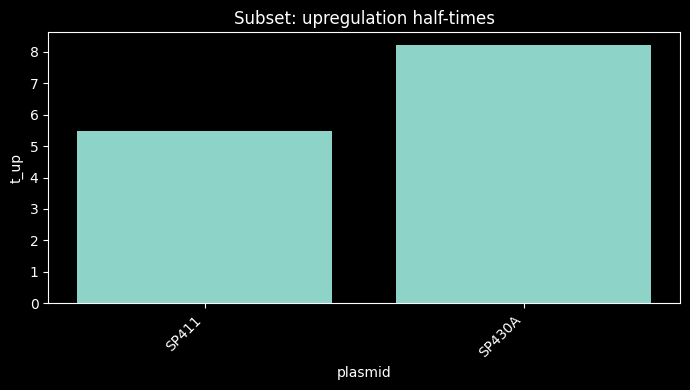

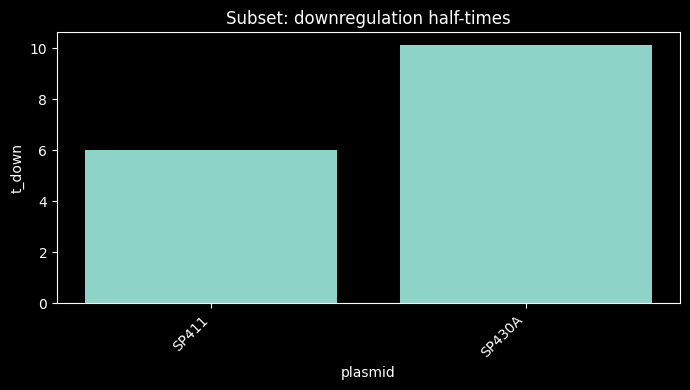

In [27]:
# Helper: find likely columns robustly
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Plot half-times if present
up = tables.get("half_times_upregulation")
down = tables.get("half_times_downregulation")

if up is not None:
    ycol = find_col(up, ["t_up","t_up_hat","halftime","half_time","t_half","t1/2"])
    if ycol:
        fig, ax = plt.subplots(figsize=(7,4))
        ax.bar(up["plasmid"].astype(str), up[ycol].astype(float))
        ax.set_title("Subset: upregulation half-times")
        ax.set_xlabel("plasmid")
        ax.set_ylabel(ycol)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("Upregulation table found but couldn't identify a half-time column.")

if down is not None:
    ycol = find_col(down, ["t_down","t_down_hat","halftime","half_time","t_half","t1/2"])
    if ycol:
        fig, ax = plt.subplots(figsize=(7,4))
        ax.bar(down["plasmid"].astype(str), down[ycol].astype(float))
        ax.set_title("Subset: downregulation half-times")
        ax.set_xlabel("plasmid")
        ax.set_ylabel(ycol)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("Downregulation table found but couldn't identify a half-time column.")


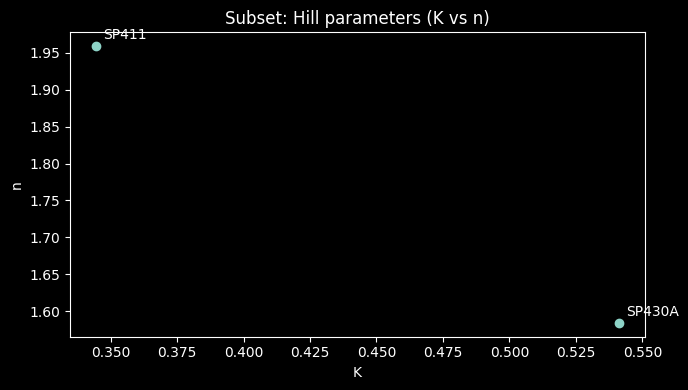

In [28]:
# Plot Hill parameters if present
hill = tables.get("Hill_parameters")
if hill is not None:
    Kcol = find_col(hill, ["K","K_hat","K_median","K_est"])
    ncol = find_col(hill, ["n","n_hat","hill_n","n_est"])

    if Kcol and ncol and "plasmid" in hill.columns:
        fig, ax = plt.subplots(figsize=(7,4))
        ax.scatter(hill[Kcol].astype(float), hill[ncol].astype(float))
        for _, r in hill.iterrows():
            ax.annotate(str(r["plasmid"]), (float(r[Kcol]), float(r[ncol])), xytext=(5,5), textcoords="offset points")
        ax.set_title("Subset: Hill parameters (K vs n)")
        ax.set_xlabel(Kcol)
        ax.set_ylabel(ncol)
        plt.tight_layout()
        plt.show()
    else:
        print("Hill table found but missing expected columns (plasmid, K, n).")


## 9) Open the generated plot PDFs (optional)

Jupyter can usually render PDFs inline. If it doesn’t, you’ll still see clickable paths.


In [29]:
from pathlib import Path
from IPython.display import display, IFrame

pdfs = sorted((tmp_root/"plots").glob("*.pdf"))
if not pdfs:
    print("No PDFs found in tmp_root/plots")
else:
    print("PDFs:")
    for p in pdfs:
        print(" -", p)
    # Show the first PDF inline
    first = pdfs[0]
    display(IFrame(src=str(first), width=900, height=600))


PDFs:
 - /tmp/castuner_subset_hs96c1mp/plots/Hill_CasRx.pdf
 - /tmp/castuner_subset_hs96c1mp/plots/KD_CasRx_fitting.pdf
 - /tmp/castuner_subset_hs96c1mp/plots/REV_CasRx_fitting.pdf


## 6) Sanity-check: show the subset parameter tables


In [30]:
for f in sorted((PROJECT_ROOT/"parameters_subset").glob("*.csv")):
    print("\n==", f.name, "==")
    display(pd.read_csv(f).head(10))



== Hill_parameters.csv ==


,plasmid,K,n
0,SP411,0.168855,1.297358



== half_times_downregulation.csv ==


,plasmid,halftime,se
0,SP411,0.227571,0.017819



== half_times_upregulation.csv ==


,plasmid,halftime,se
0,SP411,8.022125,1.822608
